# Load in base packetsizes and assignment tensors, compute ground-truth groupings

In [1]:
from pathlib import Path
from typing import List, Tuple, Optional, Dict
import numpy as np
import pandas as pd
import torch
import json

def load_dataset(load_dir: Path, device: torch.device):
    X   = torch.load(load_dir / "X.pt",                 map_location=device)
    y   = torch.load(load_dir / "y_boundary.pt",        map_location=device).to(torch.bool)
    m   = torch.load(load_dir / "mask.pt",              map_location=device).to(torch.bool)
    fa  = torch.load(load_dir / "frame_assignments.pt", map_location=device).to(torch.int64)
    lengths    = np.load(load_dir / "lengths.npy")
    num_frames = np.load(load_dir / "num_frames.npy")

    paths_file = load_dir / "paths.txt"
    if paths_file.exists():
        with paths_file.open("r") as f:
            paths = [Path(line.strip()) for line in f if line.strip()]
    else:
        paths = []

    print(f"[load_dataset] Loaded from {load_dir.resolve()}")
    print(f"  X: {tuple(X.shape)} {X.dtype} on {X.device}")
    print(f"  y_boundary: {tuple(y.shape)} {y.dtype} on {y.device}")
    print(f"  frame_assignments: {tuple(fa.shape)} {fa.dtype} on {fa.device}")
    print(f"  mask shape: {tuple(m.shape)} {m.dtype} on {m.device}")
    print(f"  lengths shape: {lengths.shape}, num_frames shape: {num_frames.shape}")
    return X, y, m, fa, paths, lengths, num_frames

import torch

@torch.no_grad()
def true_frame_packet_sums(X: torch.Tensor, y: torch.Tensor):
    """
    Compute ground-truth packet-size sums per frame for every sequence.

    Inputs
      X: [S, N_max, 2]  (X[...,0] = Δtime, X[...,1] = frame.len), PAD = -1.0
      y: [S, N_max]     bool boundary-at-frame-end, PAD = False

    Returns
      sums_list:   list of length S; each item is 1D tensor [F_i] of frame sums
      sums_padded: [S, F_max] tensor (0-padded) of frame sums
      frame_counts:[S] tensor with number of frames F_i per sequence
    """
    S, N_max, _ = X.shape
    device = X.device

    # validity from padding convention
    valid = (X[..., 0] >= 0)  # [S, N_max]  True where token is real

    sums_list = []
    frame_counts = []

    for s in range(S):
        v = valid[s]                    # [N_max]
        if not bool(v.any()):
            sums_list.append(torch.zeros(0, device=device, dtype=X.dtype))
            frame_counts.append(torch.tensor(0, device=device, dtype=torch.long))
            continue

        sizes = X[s, v, 1]              # [Tv] packet sizes (float)
        ends  = y[s, v].bool()          # [Tv] True at end-of-frame

        end_idx = torch.nonzero(ends, as_tuple=False).flatten()  # [F_i]
        if end_idx.numel() == 0:
            sums_list.append(torch.zeros(0, device=device, dtype=X.dtype))
            frame_counts.append(torch.tensor(0, device=device, dtype=torch.long))
            continue

        # cumulative sum trick: frame_sums[k] = csum[end_k] - csum[end_{k-1}]
        csum = sizes.cumsum(dim=0)                                # [Tv]
        prev_csum = torch.cat([torch.zeros(1, device=device, dtype=X.dtype),
                               csum[end_idx[:-1]]])               # [F_i]
        frame_sums = csum[end_idx] - prev_csum                    # [F_i]

        sums_list.append(frame_sums)
        frame_counts.append(torch.tensor(frame_sums.numel(), device=device, dtype=torch.long))

    frame_counts = torch.stack(frame_counts, dim=0)               # [S]
    F_max = int(frame_counts.max().item()) if frame_counts.numel() else 0

    # build a padded [S, F_max] tensor (zeros where no frame)
    sums_padded = torch.zeros((S, F_max), device=device, dtype=X.dtype)
    for s, fs in enumerate(sums_list):
        if fs.numel() > 0:
            L = min(F_max, fs.numel())
            sums_padded[s, :L] = fs[:L]
    sums_padded = sums_padded.view(int(S/4), 4, F_max)

    return sums_padded, frame_counts


In [2]:
device = "cpu"
seed_identifier = "seed1"
carla_run_identifier = "separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy"
network_configuration = "bw100mbit_delay20_jitter5_loss0"

TENSOR_ROOT = Path(f"/home/gaofeng/zanoria/grayassets_datasets/{seed_identifier}/{carla_run_identifier}/tensors/packetsizes/{network_configuration}")

X, y, mask, frame_assignments, paths, lengths, num_frames = load_dataset(
    TENSOR_ROOT/"packet_grouping_training_tensors", device=torch.device(device)
)

framesize_tensor = torch.load(Path(f"/home/gaofeng/zanoria/grayassets_datasets/{seed_identifier}/{carla_run_identifier}/tensors/frame_size_tensor.pt"))
framesize_tensor = framesize_tensor.permute(0,2,1)

ground_truth_grouped_tensor, frame_counts = true_frame_packet_sums(X, y)
grouped_tensor = torch.load(TENSOR_ROOT / "learned_grouping_tensor.pt", map_location=torch.device("cpu"))

normalized_grouped_tensor = torch.load(TENSOR_ROOT / "normalized_learned_grouping_tensor.pt")

print(ground_truth_grouped_tensor.shape)
print(framesize_tensor.shape)
print(grouped_tensor.shape)
print(normalized_grouped_tensor.shape)

exp_index = 10
cam_index = 2
print(f"\n ########### Probing the front of Experiment Index {exp_index}, Camera Index {cam_index} \n")
for i in range(10): 
    print(f"Ground Truth Grouped Tensor GoP {i}: ", ground_truth_grouped_tensor[exp_index,cam_index,i*10:(i+1)*10].tolist())
    # print(f"Framesize Tensor GoP {i}: ", framesize_tensor[exp_index,cam_index,i*10:(i+1)*10].tolist())
    print(f"Learned Grouped Tensor GoP {i}: ", grouped_tensor[exp_index,cam_index,i*10:(i+1)*10].tolist())
    print(f"GTG to LG Diff: ", (grouped_tensor[exp_index,cam_index,i*10:(i+1)*10] - ground_truth_grouped_tensor[exp_index,cam_index,i*10:(i+1)*10]).tolist())
    print(f"LGT to Framesize Ratio: ", (grouped_tensor[exp_index,cam_index,i*10:(i+1)*10]/framesize_tensor[exp_index,cam_index,i*10:(i+1)*10]).tolist())
    # print(f"Learned Normalized Grouped Tensor GoP {i}: ", normalized_grouped_tensor[exp_index,cam_index,i*10:(i+1)*10].tolist())
    print()
    


[load_dataset] Loaded from /home/gaofeng/zanoria/grayassets_datasets/seed1/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/tensors/packetsizes/bw100mbit_delay20_jitter5_loss0/packet_grouping_training_tensors
  X: (4040, 12515, 2) torch.float32 on cpu
  y_boundary: (4040, 12515) torch.bool on cpu
  frame_assignments: (4040, 12515) torch.int64 on cpu
  mask shape: (4040, 12515) torch.bool on cpu
  lengths shape: (4040,), num_frames shape: (4040,)
torch.Size([1010, 4, 480])
torch.Size([1010, 4, 480])
torch.Size([1010, 4, 480])
torch.Size([1010, 4, 480])

 ########### Probing the front of Experiment Index 10, Camera Index 2 

Ground Truth Grouped Tensor GoP 0:  [200575.0, 4357.0, 5714.0, 10049.0, 10310.0, 11547.0, 8943.0, 17849.0, 14308.0, 12806.0]
Learned Grouped Tensor GoP 0:  [200575.0, 4357.0, 5714.0, 10049.0, 10310.0, 11547.0, 8943.0, 17849.0, 14308.0, 12806.0]
GTG to LG Diff:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
LGT to Fram

# Compare ground truth tensors between NESL and LICOS machines

In [3]:
seed_identifier = "seed1"
carla_run_identifier = "separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy"
network_configuration = "bw100mbit_delay20_jitter5_loss0"

nesl_position_gt_tensor = torch.load(f"/home/gaofeng/zanoria/grayassets_datasets/{seed_identifier}/{carla_run_identifier}/tensors/position_gt_tensor.pt", map_location=torch.device("cpu"))
licos_position_gt_tensor = torch.load("/home/gaofeng/zanoria/notebooks_to_run/scratch_notebooks/files/LICOS_bw50_delay20_jitter5_position_gt_tensor.pt", map_location=torch.device("cpu"))

print((nesl_position_gt_tensor - licos_position_gt_tensor).sum())

tensor(0.)


# Plot normalized tensor

(1010, 4, 480)


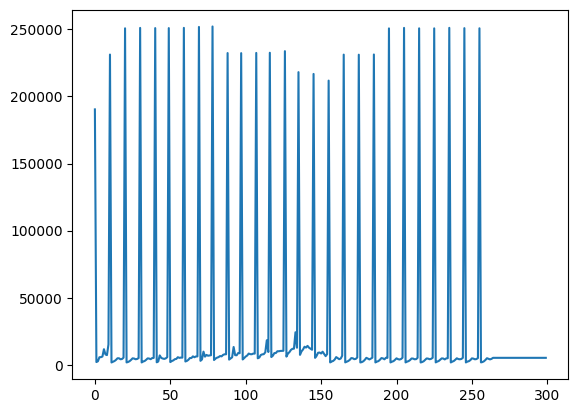

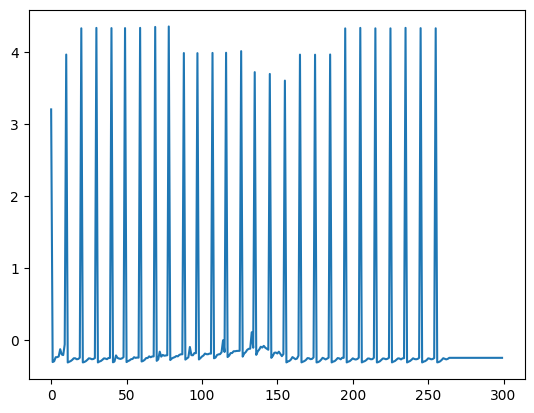

In [11]:
seed_identifier = "seed1"
carla_run_identifier = "separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy"
network_configuration = "bw100mbit_delay20_jitter5_loss0"

recon_frame_tensor = torch.load(f"/home/gaofeng/zanoria/grayassets_datasets/{seed_identifier}/{carla_run_identifier}/tensors/packetsizes/{network_configuration}/learned_grouping_tensor.pt", map_location=torch.device("cpu")).numpy()
norm_recon_frame_tensor = torch.load(f"/home/gaofeng/zanoria/grayassets_datasets/{seed_identifier}/{carla_run_identifier}/tensors/packetsizes/{network_configuration}/normalized_learned_grouping_tensor.pt", map_location=torch.device("cpu")).numpy()
print(recon_frame_tensor.shape)

import matplotlib.pyplot as plt

plt.plot(recon_frame_tensor[0,0,:300])
plt.show()
plt.plot(norm_recon_frame_tensor[0,0,:300])
plt.show()